In [ ]:
# ============================================================
# Google Drive mount
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

DATA_DIR = "/content/drive/MyDrive/Epigenomics_corpus/FullText_Epigenomics_data240126(최종)"

data = []

for fname in tqdm(os.listdir(DATA_DIR)):
    if fname.endswith(".txt"):
        file_path = os.path.join(DATA_DIR, fname)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        doc_id = fname.replace(".txt", "")
        data.append([doc_id, text])

df = pd.DataFrame(data, columns=["doc_id", "text"])

# 결과 확인
print(df.shape)
print(df.head())

# CSV로 저장
save_path = "/content/drive/MyDrive/epigenomics_fulltext_df.csv"
df.to_csv(save_path, index=False, encoding="utf-8-sig")

print(f"\nSaved to: {save_path}")

100%|██████████| 6153/6153 [35:47<00:00,  2.87it/s]


(6152, 2)
         doc_id                                               text
0  pmc_10796827  \n\n\npmc\n\nComput Struct Biotechnol JComput ...
1  pmc_10787126  \n\n\npmc\n\nGenomics Proteomics Bioinformatic...
2  pmc_10787124  \n\n\npmc\n\nGenomics Proteomics Bioinformatic...
3  pmc_10787103  \n\n\npmc\n\nAdv Sci (Weinh)Adv Sci (Weinh)10....
4  pmc_10786392  \n\n\npmc\n\nPLoS OnePLoS OneplosPLOS ONE1932-...

Saved to: /content/drive/MyDrive/epigenomics_fulltext_df.csv


Data shape: (6152, 2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/385 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


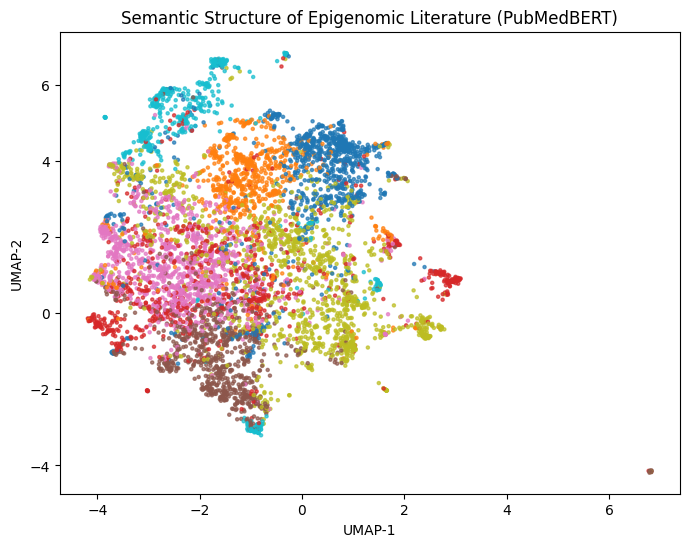

All steps completed successfully.


In [ ]:
# =====================================
# 1. 데이터 불러오기
# =====================================
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/epigenomics_fulltext_df.csv")

print("Data shape:", df.shape)


# =====================================
# 2. 라이브러리 설치
# =====================================
!pip install -q sentence-transformers umap-learn scikit-learn


# =====================================
# 3. 모델 로드 (PubMedBERT)
# =====================================
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("pritamdeka/S-PubMedBERT-MS-MARCO")


# =====================================
# 4. 텍스트 길이 제한 (중요: 메모리 안정)
# =====================================
def truncate_text(text, max_chars=2000):
    return str(text)[:max_chars]

df["text_short"] = df["text"].apply(truncate_text)


# =====================================
# 5. Embedding 생성
# =====================================
import numpy as np

embeddings = model.encode(
    df["text_short"].tolist(),
    batch_size=16,
    show_progress_bar=True
)

# 저장
np.save("/content/drive/MyDrive/epigenomics_embeddings.npy", embeddings)


# =====================================
# 6. UMAP 차원 축소
# =====================================
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# 저장
umap_df = pd.DataFrame(embedding_2d, columns=["umap_1", "umap_2"])
umap_df["doc_id"] = df["doc_id"]

umap_df.to_csv("/content/drive/MyDrive/epigenomics_umap.csv",
               index=False, encoding="utf-8-sig")


# =====================================
# 7. KMeans clustering (semantic cluster)
# =====================================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, random_state=42)
clusters = kmeans.fit_predict(embeddings)

df["semantic_cluster"] = clusters

df.to_csv("/content/drive/MyDrive/epigenomics_with_clusters.csv",
          index=False, encoding="utf-8-sig")


# =====================================
# 8. 시각화 (논문용 600dpi)
# =====================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=clusters,
    cmap="tab10",
    s=5,
    alpha=0.7
)

plt.title("Semantic Structure of Epigenomic Literature (PubMedBERT)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# PNG (600dpi)
plt.savefig("/content/drive/MyDrive/Figure_semantic_umap.png",
            dpi=600, bbox_inches="tight")

# PDF (벡터)
plt.savefig("/content/drive/MyDrive/Figure_semantic_umap.pdf",
            bbox_inches="tight")

plt.show()

print("All steps completed successfully.")

In [ ]:
# =====================================
# 0. 데이터 불러오기
# =====================================
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/epigenomics_with_clusters.csv")
# df에는 doc_id, text, text_short, semantic_cluster 가 있어야 함

print(df.shape)


# =====================================
# 1. 각 클러스터 대표 문서 추출
# =====================================
import os

output_text = []

for i in sorted(df["semantic_cluster"].unique()):
    subset = df[df["semantic_cluster"] == i]

    # 앞쪽 문서 3개만 대표로 선택
    samples = subset.head(3)["text_short"].tolist()

    output_text.append(f"\n=== Cluster {i} Representative Documents ===\n")

    for idx, s in enumerate(samples):
        output_text.append(f"[Doc {idx+1}]\n{s[:500]}\n")

# 파일 저장
with open("/content/drive/MyDrive/cluster_representative_docs.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(output_text))

print("Representative documents saved.")


# =====================================
# 2. 클러스터별 키워드 추출 (TF-IDF)
# =====================================
from sklearn.feature_extraction.text import TfidfVectorizer

keyword_results = []

for i in sorted(df["semantic_cluster"].unique()):
    subset = df[df["semantic_cluster"] == i]

    texts = subset["text_short"].tolist()

    vectorizer = TfidfVectorizer(
        max_features=30,
        stop_words="english"
    )

    X = vectorizer.fit_transform(texts)

    keywords = vectorizer.get_feature_names_out()

    keyword_results.append({
        "cluster": i,
        "keywords": ", ".join(keywords)
    })

# CSV 저장
keyword_df = pd.DataFrame(keyword_results)

keyword_df.to_csv(
    "/content/drive/MyDrive/cluster_keywords.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Cluster keywords saved.")


# =====================================
# 3. (선택) cluster 분포 확인
# =====================================
cluster_counts = df["semantic_cluster"].value_counts().sort_index()

cluster_counts.to_csv(
    "/content/drive/MyDrive/cluster_distribution.csv",
    encoding="utf-8-sig"
)

print("Cluster distribution saved.")

(6152, 4)
Representative documents saved.
Cluster keywords saved.
Cluster distribution saved.


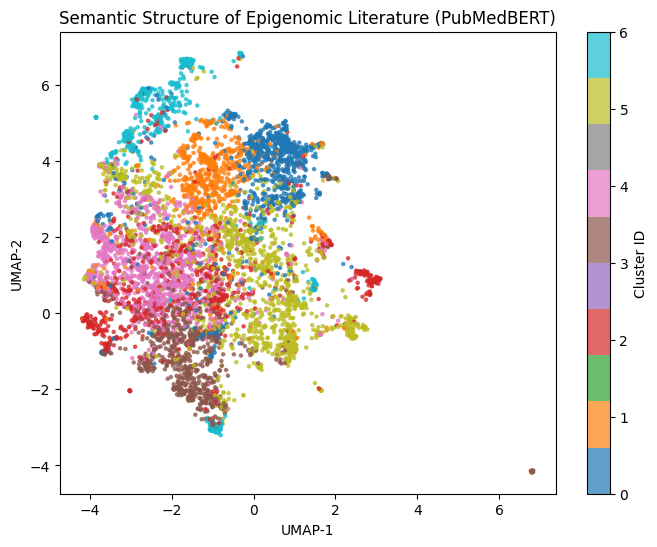

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 데이터 불러오기
# ===============================
df = pd.read_csv("/content/drive/MyDrive/epigenomics_with_clusters.csv")
umap_df = pd.read_csv("/content/drive/MyDrive/epigenomics_umap.csv")

clusters = df["semantic_cluster"].values
embedding_2d = umap_df[["umap_1", "umap_2"]].values

# ===============================
# 시각화 (범례 포함)
# ===============================
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=clusters,
    cmap="tab10",
    s=5,
    alpha=0.7
)

# 컬러바 (cluster 번호)
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster ID")

plt.title("Semantic Structure of Epigenomic Literature (PubMedBERT)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# 저장 (600dpi)
plt.savefig("/content/drive/MyDrive/Figure_semantic_umap_with_legend.png",
            dpi=600, bbox_inches="tight")

plt.savefig("/content/drive/MyDrive/Figure_semantic_umap_with_legend.pdf",
            bbox_inches="tight")

plt.show()